# 02 — Banking Fraud Detection: Evaluation (costo de negocio)

Continúa desde [`03_modeling.ipynb`](./03_modeling.ipynb), que eligió XGBoost + SMOTE por PR-AUC. Este notebook traduce ese modelo en una decisión operativa: **qué umbral de probabilidad conviene usar**, dado el costo real de dejar pasar un fraude frente al costo de investigar una alerta.

**Diferencia clave frente a `04_evaluation.ipynb` de project 01:** ahí los costos eran completamente ilustrativos. Acá el dataset trae el monto real de cada transacción (`Amount`), así que el costo de un fraude no detectado no es un número inventado — es la plata que efectivamente se pierde. Solo el costo de investigar una alerta (`ADMIN_COST`) sigue siendo un supuesto ilustrativo, porque el dataset no trae ese dato.

**Matriz de costo usada** (formulación estándar para este tipo de problema, ej. Dal Pozzolo et al.):

| | Predicho: legítima | Predicho: fraude |
|---|---|---|
| **Real: legítima** | 0 | `ADMIN_COST` (fricción/investigación innecesaria) |
| **Real: fraude** | `Amount` (pérdida total) | `ADMIN_COST` (se contuvo, pero igual hay que investigarlo) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Reentrenar el modelo ganador

Mismos hiperparámetros y mismo split que en `03_modeling.ipynb`.

In [2]:
train = pd.read_csv('../data/processed_train.csv')
test = pd.read_csv('../data/processed_test.csv')

X_train = train.drop(columns=['Class'])
y_train = train['Class']
X_test = test.drop(columns=['Class'])
y_test = test['Class']
amounts_test = test['Amount'].values

X_train_res, y_train_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, eval_metric='aucpr', random_state=RANDOM_STATE,
).fit(X_train_res, y_train_res)

proba = xgb.predict_proba(X_test)[:, 1]
print('Modelo reentrenado. Fraude total en test:', f"${amounts_test[y_test.values == 1].sum():,.2f}", 'en', y_test.sum(), 'transacciones.')

Modelo reentrenado. Fraude total en test: $7,727.67 en 74 transacciones.


## 2. Función de costo

In [3]:
ADMIN_COST = 10  # costo ilustrativo de investigar/bloquear UNA transacción marcada (TP o FP)

def total_cost(y_true, proba, amounts, threshold, admin_cost=ADMIN_COST):
    pred = (proba >= threshold).astype(int)
    y_true = np.asarray(y_true)
    fn_mask = (y_true == 1) & (pred == 0)
    flagged_mask = (pred == 1)  # TP + FP, ambos cuestan ADMIN_COST
    cost = amounts[fn_mask].sum() + admin_cost * flagged_mask.sum()
    return cost, fn_mask.sum(), flagged_mask.sum()

## 3. Costo total en función del umbral

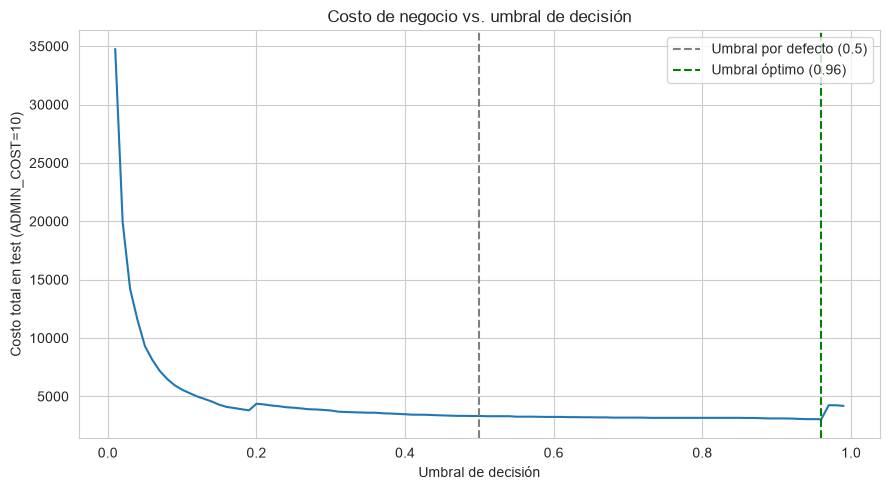

Umbral óptimo: 0.96 | costo mínimo: $3,041.01
Umbral por defecto (0.5): costo = $3,321.01


In [4]:
thresholds = np.linspace(0.01, 0.99, 99)
costs = [total_cost(y_test, proba, amounts_test, t)[0] for t in thresholds]

opt_idx = int(np.argmin(costs))
opt_threshold = thresholds[opt_idx]
opt_cost = costs[opt_idx]
default_cost = total_cost(y_test, proba, amounts_test, 0.5)[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, costs)
ax.axvline(0.5, linestyle='--', color='gray', label='Umbral por defecto (0.5)')
ax.axvline(opt_threshold, linestyle='--', color='green', label=f'Umbral óptimo ({opt_threshold:.2f})')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel(f'Costo total en test (ADMIN_COST={ADMIN_COST})')
ax.set_title('Costo de negocio vs. umbral de decisión')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Umbral óptimo: {opt_threshold:.2f} | costo mínimo: ${opt_cost:,.2f}')
print(f'Umbral por defecto (0.5): costo = ${default_cost:,.2f}')

**Nota sobre el resultado:** el umbral óptimo puede terminar bastante más alto que 0.5. Tiene sentido en esta matriz de costo: como *cada* transacción marcada (sea TP o FP) cuesta `ADMIN_COST`, subir el umbral filtra falsas alarmas sin perder los fraudes que el modelo ya detectaba con alta confianza — reduce el volumen de revisión manual sin resignar detección. Esto es lo opuesto a lo que muchos esperarían intuitivamente ("bajar el umbral para atrapar más fraude"), y es exactamente el tipo de resultado contraintuitivo que justifica optimizar el umbral con la matriz de costo real en vez de asumir 0.5 o "cuanto más bajo, mejor".

## 4. Comparación contra estrategias sin modelo

In [5]:
cost_never_alert = amounts_test[y_test.values == 1].sum()  # se pierde el 100% del fraude
cost_always_alert = ADMIN_COST * len(y_test)                # se investiga cada transacción

comparison = pd.DataFrame({
    'estrategia': [
        'Sin modelo — nunca alertar',
        'Sin modelo — alertar siempre',
        'XGBoost+SMOTE — umbral default (0.5)',
        f'XGBoost+SMOTE — umbral óptimo ({opt_threshold:.2f})',
    ],
    'costo_total': [cost_never_alert, cost_always_alert, default_cost, opt_cost],
})
comparison['ahorro_vs_nunca_alertar'] = cost_never_alert - comparison['costo_total']
comparison['ahorro_%'] = (comparison['ahorro_vs_nunca_alertar'] / cost_never_alert * 100).round(1)
comparison

,estrategia,costo_total,ahorro_vs_nunca_alertar,ahorro_%
0,Sin modelo — nunca alertar,7727.67,0.00,0.0
1,Sin modelo — alertar siempre,567460.00,-559732.33,-7243.2
2,XGBoost+SMOTE — umbral default (0.5),3321.01,4406.66,57.0
3,XGBoost+SMOTE — umbral óptimo (0.96),3041.01,4686.66,60.6


**Otro resultado que vale la pena señalar:** "alertar siempre" es, acá, la peor estrategia posible — mucho peor que no hacer nada. Investigar las ~56.700 transacciones del período de test a `ADMIN_COST` cada una cuesta muchísimo más que el fraude total que hay que prevenir. Es el argumento cuantitativo más claro a favor de tener un modelo: sin él, la única alternativa razonable sería no alertar nunca; el modelo abre una tercera opción que resulta muchísimo más barata que ambos extremos.

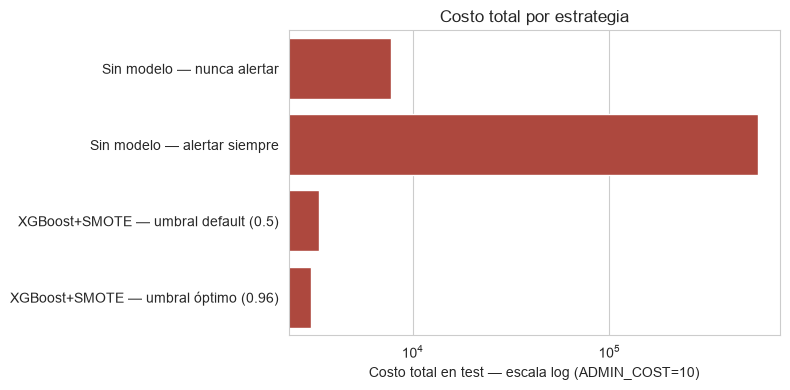

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=comparison, x='costo_total', y='estrategia', ax=ax, color='#c0392b')
ax.set_xscale('log')
ax.set_xlabel('Costo total en test — escala log (ADMIN_COST=' + str(ADMIN_COST) + ')')
ax.set_ylabel('')
ax.set_title('Costo total por estrategia')
plt.tight_layout()
plt.show()

## 5. Matriz de confusión: default vs. óptimo

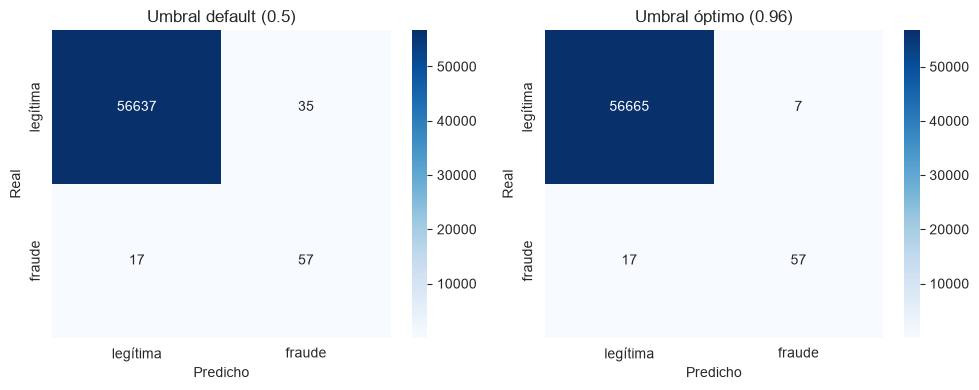

Default (0.5):  17 fraudes no detectados, 92 transacciones marcadas para revisión
Óptimo (0.96): 17 fraudes no detectados, 64 transacciones marcadas para revisión


In [7]:
pred_default = (proba >= 0.5).astype(int)
pred_opt = (proba >= opt_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (thr, pred, title) in zip(axes, [
    (0.5, pred_default, 'Umbral default (0.5)'),
    (opt_threshold, pred_opt, f'Umbral óptimo ({opt_threshold:.2f})'),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['legítima', 'fraude'], yticklabels=['legítima', 'fraude'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

_, fn_default, flagged_default = total_cost(y_test, proba, amounts_test, 0.5)
_, fn_opt, flagged_opt = total_cost(y_test, proba, amounts_test, opt_threshold)
print(f'Default (0.5):  {fn_default} fraudes no detectados, {flagged_default} transacciones marcadas para revisión')
print(f'Óptimo ({opt_threshold:.2f}): {fn_opt} fraudes no detectados, {flagged_opt} transacciones marcadas para revisión')

## 6. Análisis de sensibilidad: ¿qué pasa si `ADMIN_COST` es distinto?

`ADMIN_COST` es el único supuesto ilustrativo de este notebook — el costo del fraude en sí (`Amount`) es real. Esta sección muestra cómo cambia el umbral recomendado según cuánto cueste investigar cada alerta.

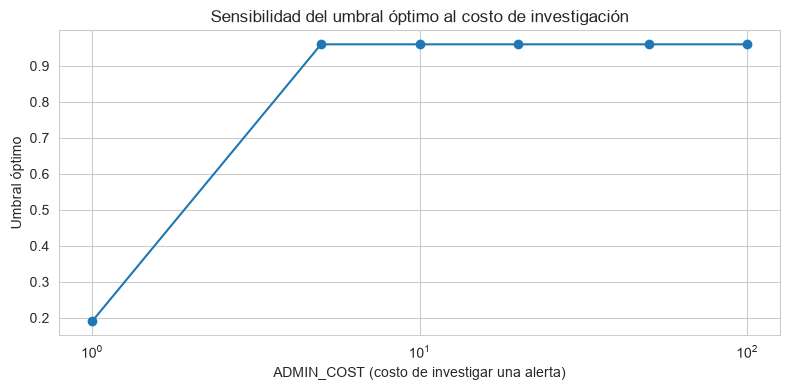

,admin_cost,umbral_optimo
0,1,0.19
1,5,0.96
2,10,0.96
3,20,0.96
4,50,0.96
5,100,0.96


In [8]:
admin_costs = [1, 5, 10, 20, 50, 100]
sensitivity = []
for ac in admin_costs:
    costs_ac = [total_cost(y_test, proba, amounts_test, t, admin_cost=ac)[0] for t in thresholds]
    best_t = thresholds[int(np.argmin(costs_ac))]
    sensitivity.append({'admin_cost': ac, 'umbral_optimo': best_t})

sensitivity_df = pd.DataFrame(sensitivity)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sensitivity_df['admin_cost'], sensitivity_df['umbral_optimo'], marker='o')
ax.set_xscale('log')
ax.set_xlabel('ADMIN_COST (costo de investigar una alerta)')
ax.set_ylabel('Umbral óptimo')
ax.set_title('Sensibilidad del umbral óptimo al costo de investigación')
plt.tight_layout()
plt.show()

sensitivity_df

A menor `ADMIN_COST`, conviene un umbral más bajo (alertar más, porque revisar de más sale barato). A mayor `ADMIN_COST`, conviene subir el umbral — cada revisión pesa más, así que solo vale la pena marcar los casos donde el modelo está muy seguro. Esta es exactamente la conversación que hay que tener con el equipo de fraude/operaciones antes de fijar el `ADMIN_COST` real: cuánto cuesta, en tiempo de analista y fricción con el cliente, revisar una alerta.

## 7. Conclusiones de la fase de Evaluation

1. **El costo del fraude no detectado es real, no ilustrativo:** a diferencia de project 01, acá se usó el monto real de cada transacción (`Amount`) como el costo de un falso negativo. Solo `ADMIN_COST` (costo de investigar una alerta) sigue siendo un supuesto — debe reemplazarse por la cifra real del equipo de operaciones antes de producción.
2. **El umbral óptimo no es 0.5**, y en este caso resultó *más alto* que el default — un resultado contraintuitivo que solo aparece al modelar el costo real: como cada alerta (TP o FP) tiene el mismo costo de revisión, filtrar falsas alarmas sin perder los fraudes de alta confianza reduce el costo total.
3. **"Alertar siempre" es la peor estrategia posible** en esta matriz de costo — mucho peor que no alertar nunca. El valor del modelo está precisamente en evitar ambos extremos.
4. **El ahorro real depende de `ADMIN_COST`**, que no está en el dataset — la sección 6 deja explícito cómo se mueve la recomendación según ese supuesto, para poder tener la conversación con el dueño del proceso antes de fijar un umbral en producción.
5. **Limitación heredada de `03_modeling.ipynb`:** el modelo ganador (XGBoost+SMOTE) tiene PR-AUC 0.79 — bueno, pero lejos de perfecto. El costo mostrado acá asume que ese modelo seguirá generalizando igual de bien fuera del período de test evaluado (~48h de datos), lo cual debería revalidarse con más historia antes de decidir un umbral definitivo.

**Siguiente paso:** llevar este análisis a un dashboard en Streamlit (`dashboard/`), con `ADMIN_COST` como parámetro ajustable — cerrando el ciclo de storytelling del proyecto, igual que en project 01.